In [1]:
# CELL 1: Upload the RAVDESS ZIP file
from google.colab import files
uploaded = files.upload()  # Select ravdess-emotional-speech-audio.zip

Saving archive.zip to archive.zip


In [4]:
# CELL 2: Unzip it
!unzip -q /content/archive.zip
!ls  # Check what folders were created

Actor_01  Actor_06  Actor_11  Actor_16	Actor_21     audio_speech_actors_01-24
Actor_02  Actor_07  Actor_12  Actor_17	Actor_22     sample_data
Actor_03  Actor_08  Actor_13  Actor_18	Actor_23
Actor_04  Actor_09  Actor_14  Actor_19	Actor_24
Actor_05  Actor_10  Actor_15  Actor_20	archive.zip


In [5]:
# CELL 3: Import all libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, Conv1D,
    MaxPooling1D, Flatten, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(" All libraries imported!")
print(f"TensorFlow version: {tf.__version__}")

 All libraries imported!
TensorFlow version: 2.20.0


In [6]:
# CELL 4: Dataset exploration
DATA_PATH = "audio_speech_actors_01-24/"  # Adjust if folder name is different

# Check folder structure
for root, dirs, files in os.walk(DATA_PATH):
    wav_files = [f for f in files if f.endswith('.wav')]
    if wav_files:
        print(f" {root}")
        print(f"   Files: {len(wav_files)}")
        print(f"   Example: {wav_files[0]}")
        break

print("\n Target emotions:")
print("   03 = happy")
print("   04 = sad")
print("   05 = angry")

 audio_speech_actors_01-24/Actor_07
   Files: 60
   Example: 03-01-05-01-02-01-07.wav

 Target emotions:
   03 = happy
   04 = sad
   05 = angry


In [8]:
# FIX CELL: Install missing dependency
!pip install resampy -q
print("✅ resampy installed")


# CELL 5: MFCC Feature Extraction (FIXED)

import os
import numpy as np
import librosa

# FIXED: Actors are directly in /content/, not in a subfolder
# Check your ls output: Actor_01, Actor_02... are in /content/
DATA_PATH = "/content/"  # <-- FIXED PATH

def extract_mfcc(file_path, n_mfcc=40, max_pad_len=174):
    """
    Extract MFCC features from an audio file
    """
    try:
        # FIXED: Remove res_type to avoid resampy issue, or use 'soxr_hq'
        audio, sample_rate = librosa.load(file_path, duration=3, res_type='soxr_hq')

        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)

        # Pad or truncate to fixed length
        if mfccs.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfccs = mfccs[:, :max_pad_len]

        return mfccs.T  # Shape: (time_steps, n_mfcc)

    except Exception as e:
        print(f" Error: {file_path} - {e}")
        return None

# Test on one file
test_file = None
for root, dirs, files in os.walk(DATA_PATH):
    # Only look in Actor folders, skip other directories
    if 'Actor_' in root:
        wav_files = [f for f in files if f.endswith('.wav')]
        if wav_files:
            test_file = os.path.join(root, wav_files[0])
            break

if test_file:
    test_mfcc = extract_mfcc(test_file)
    print(f" Test MFCC shape: {test_mfcc.shape}")
    print(f"   File: {os.path.basename(test_file)}")
else:
    print(" No audio files found. Check DATA_PATH.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 51.2 MB/s eta 0:00:00
✅ resampy installed
 Test MFCC shape: (174, 40)
   File: 03-01-05-01-02-01-07.wav


In [9]:
# CELL 6: Load and process all audio files (FIXED)

TARGET_EMOTIONS = {'happy': 3, 'sad': 4, 'angry': 5}
EMOTION_NAMES = {3: 'happy', 4: 'sad', 5: 'angry'}

features = []
labels = []

print("🔄 Processing audio files...")

for root, dirs, files in os.walk(DATA_PATH):
    # FIXED: Only process Actor folders
    if 'Actor_' not in root:
        continue

    for file in files:
        if file.endswith('.wav'):
            parts = file.split('-')
            if len(parts) >= 3:
                emotion_code = int(parts[2])

                if emotion_code in TARGET_EMOTIONS.values():
                    file_path = os.path.join(root, file)

                    mfcc = extract_mfcc(file_path)

                    if mfcc is not None:
                        features.append(mfcc)
                        labels.append(emotion_code)

features = np.array(features)
labels = np.array(labels)

print(f"\n Data loaded!")
print(f"   Total samples: {len(features)}")
if len(features) > 0:
    print(f"   Feature shape: {features[0].shape}")
    print(f"\n   Emotion distribution:")
    unique, counts = np.unique(labels, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"   {EMOTION_NAMES[u]}: {c}")
else:
    print(" No features extracted. Check paths.")

🔄 Processing audio files...

 Data loaded!
   Total samples: 1152
   Feature shape: (174, 40)

   Emotion distribution:
   happy: 384
   sad: 384
   angry: 384


In [10]:
# CELL 7: Encode labels and split data

# Encode emotions to 0, 1, 2
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)  # happy=0, sad=1, angry=2 (order may vary)
labels_categorical = to_categorical(labels_encoded)

print(" Label encoding:")
for i, emotion in enumerate(le.classes_):
    print(f"   {emotion} → {i}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features, labels_categorical,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded
)

print(f"\n Data split:")
print(f"   Training: {X_train.shape[0]} samples")
print(f"   Testing: {X_test.shape[0]} samples")
print(f"   Input shape: {X_train.shape[1:]} (time_steps, features)")

 Label encoding:
   3 → 0
   4 → 1
   5 → 2

 Data split:
   Training: 921 samples
   Testing: 231 samples
   Input shape: (174, 40) (time_steps, features)


In [11]:
# CELL 8: Build the model

print("=" * 60)
print("BUILDING CNN + LSTM MODEL")
print("=" * 60)

model = Sequential([
    # CNN layers for local feature extraction
    Conv1D(64, kernel_size=3, activation='relu',
           input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # LSTM layers for temporal patterns
    LSTM(128, return_sequences=True),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.3),

    # Dense layers for classification
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(3, activation='softmax')  # 3 emotions
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n Model Architecture:")
model.summary()

BUILDING CNN + LSTM MODEL

 Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 172, 64)        │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 172, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 86, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 84, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 84, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 42, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,819 (854.76 KB)

 Trainable params: 218,307 (852.76 KB)

 Non-trainable params: 512 (2.00 KB)

In [12]:
# CELL 9: Train with callbacks

print("=" * 60)
print("TRAINING MODEL")
print("=" * 60)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("\n Training complete!")

TRAINING MODEL
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.4266 - loss: 1.2929 - val_accuracy: 0.3027 - val_loss: 1.2294 - learning_rate: 0.0010
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5856 - loss: 0.9676 - val_accuracy: 0.3514 - val_loss: 1.2059 - learning_rate: 0.0010
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6101 - loss: 0.8701 - val_accuracy: 0.3946 - val_loss: 1.0949 - learning_rate: 0.0010
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7242 - loss: 0.7176 - val_accuracy: 0.6000 - val_loss: 0.7877 - learning_rate: 0.0010
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7731 - loss: 0.5891 - val_accuracy: 0.6757 - val_loss: 0.7115 - learning_rate: 0.0010
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8234 - loss: 0.5410 - val_accuracy: 0.6973 - val_loss: 0.7072 - learning_rate: 0.0010
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8234 - loss: 0

In [13]:
# CELL 10: Evaluate model

print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Decode labels back to emotion names
emotion_labels = [EMOTION_NAMES[e] for e in le.classes_]

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\n Overall Metrics:")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")

print(f"\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=emotion_labels))

MODEL EVALUATION
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step

 Overall Metrics:
   Accuracy:  0.9048
   Precision: 0.9064
   Recall:    0.9048
   F1-Score:  0.9052

 Classification Report:
              precision    recall  f1-score   support

       happy       0.90      0.90      0.90        77
         sad       0.86      0.91      0.89        77
       angry       0.96      0.91      0.93        77

    accuracy                           0.90       231
   macro avg       0.91      0.90      0.91       231
weighted avg       0.91      0.90      0.91       231



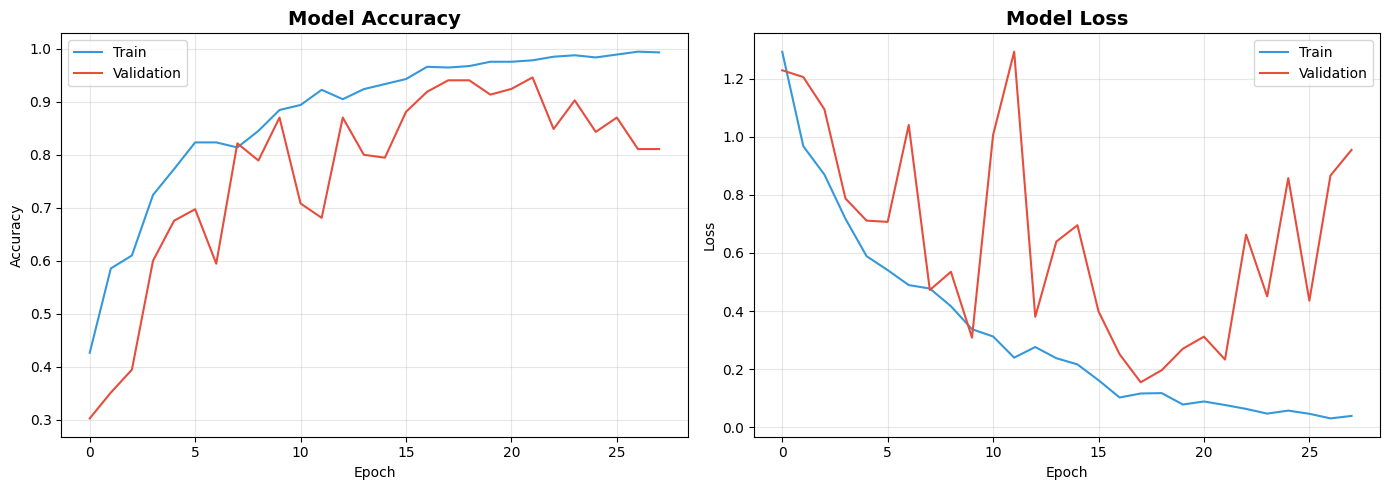

In [14]:
# CELL 11: Plot training history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', color='#3498db')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#e74c3c')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train', color='#3498db')
axes[1].plot(history.history['val_loss'], label='Validation', color='#e74c3c')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('task2_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

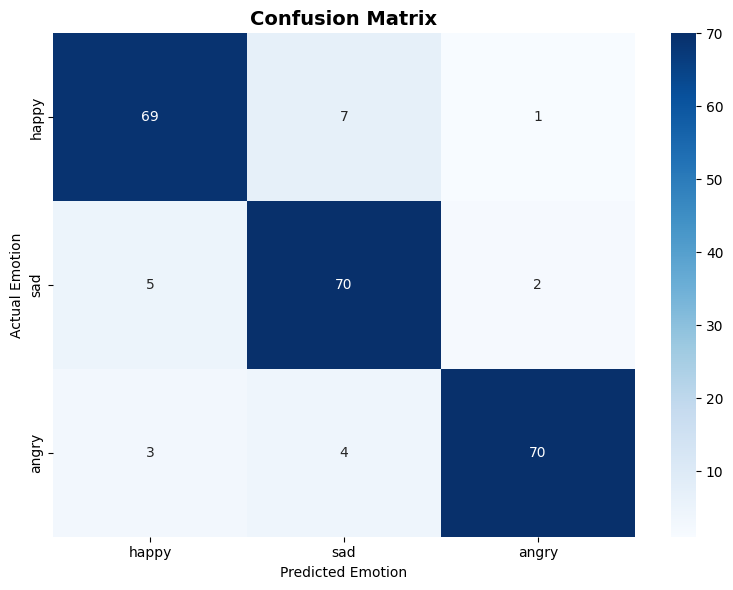

In [15]:
# CELL 12: Confusion Matrix

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Emotion')
ax.set_ylabel('Actual Emotion')

plt.tight_layout()
plt.savefig('task2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

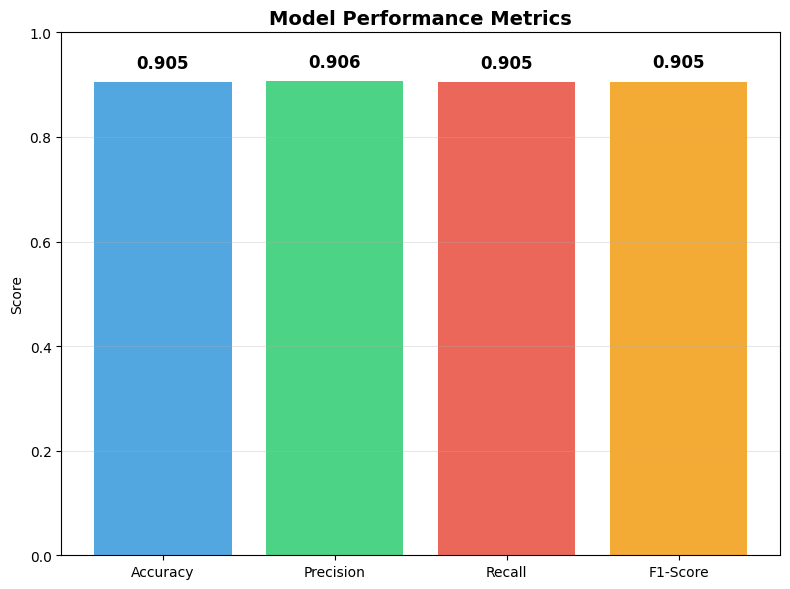

In [16]:
# CELL 13: Metrics Bar Chart

fig, ax = plt.subplots(figsize=(8, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = ax.bar(metrics, values, color=colors, alpha=0.85)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('task2_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# CELL 14: Save everything

# Save model
model.save('emotion_recognition_model.h5')
print(" Model saved: emotion_recognition_model.h5")

# Save label encoder
import joblib
joblib.dump(le, 'emotion_label_encoder.pkl')
print(" Label encoder saved: emotion_label_encoder.pkl")

# Save results
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})
results_df.to_csv('task2_results.csv', index=False)
print(" Results saved: task2_results.csv")

print("\n All files ready for download!")
print("   Download from Files panel (left side)")

 Model saved: emotion_recognition_model.h5
 Label encoder saved: emotion_label_encoder.pkl
 Results saved: task2_results.csv

 All files ready for download!
   Download from Files panel (left side)


In [18]:
# CELL 15: Predict emotion from audio file

def predict_emotion(audio_path, model, le):
    """
    Predict emotion from an audio file
    """
    mfcc = extract_mfcc(audio_path)
    if mfcc is not None:
        mfcc = np.expand_dims(mfcc, axis=0)  # Add batch dimension
        prediction = model.predict(mfcc, verbose=0)
        emotion_idx = np.argmax(prediction)
        emotion = le.inverse_transform([emotion_idx])[0]
        confidence = np.max(prediction)
        return EMOTION_NAMES[emotion], float(confidence)
    return None, None

# Test on a random file from test set
test_file_path = None
for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith('.wav'):
            parts = file.split('-')
            if len(parts) >= 3 and int(parts[2]) in TARGET_EMOTIONS.values():
                test_file_path = os.path.join(root, file)
                break
    if test_file_path:
        break

if test_file_path:
    pred_emotion, conf = predict_emotion(test_file_path, model, le)
    actual_emotion = EMOTION_NAMES[int(os.path.basename(test_file_path).split('-')[2])]
    print(f" File: {os.path.basename(test_file_path)}")
    print(f"   Actual: {actual_emotion}")
    print(f"   Predicted: {pred_emotion} (confidence: {conf:.2%})")

 File: 03-01-05-01-02-01-07.wav
   Actual: angry
   Predicted: angry (confidence: 97.91%)
